# ProShares Replication and Unconstrained Optimization: supporting code
**FINM 36700** · Ivy Chan, Jennifer Xiao, Edouard Lavalard, Alexei Le

# Part I: ProShares Hedge Replication

In [1]:
import pandas as pd, numpy as np, statsmodels.api as sm
import matplotlib.pyplot as plt
pd.options.display.float_format = '{:.4f}'.format

FILE = 'proshares_analysis_data.xlsx'
NAMES = {'HFRIFWI Index': 'HFRI', 'MLEIFCTR Index': 'MLFM', 'MLEIFCTX Index': 'MLFM-ES', 'HDG US Equity': 'HDG', 'QAI US Equity': 'QAI'}
H = pd.read_excel(FILE, sheet_name='hedge_fund_series', index_col=0).rename(columns=NAMES).dropna()
F = pd.read_excel(FILE, sheet_name='merrill_factors', index_col=0).loc[H.index]
SPY = F['SPY US Equity'].rename('SPY')
P = 12

def summary(R):
    m, v = R.mean() * P, R.std() * np.sqrt(P)
    return pd.DataFrame({'mean': m, 'vol': v, 'sharpe': m / v})

def drawdown(s):
    w = (1 + s).cumprod()
    peak = w.cummax()
    dd = w / peak - 1
    trough = dd.idxmin()
    top = w.loc[:trough].idxmax()
    rec = w.loc[trough:][w.loc[trough:] >= peak.loc[trough]]
    return pd.Series({'max drawdown': dd.min(), 'peak': top, 'trough': trough, 'recovery': rec.index[0] if len(rec) else pd.NaT})

def tail(R):
    q = R.quantile(.05)
    out = pd.DataFrame({'skewness': R.skew(), 'excess kurtosis': R.kurt(), 'VaR (.05)': q, 'CVaR (.05)': R[R <= q].mean()})
    return out.join(pd.DataFrame({c: drawdown(R[c]) for c in R}).T)

def market_reg(R, mkt):
    out = {}
    for c in R:
        fit = sm.OLS(R[c], sm.add_constant(mkt)).fit()
        a, b = fit.params
        out[c] = {'beta': b, 'treynor': R[c].mean() * P / b, 'info ratio': a * P / (fit.resid.std() * np.sqrt(P)), 'r-squared': fit.rsquared}
    return pd.DataFrame(out).T

def replicate(y, X):
    fit = sm.OLS(y, sm.add_constant(X)).fit()
    return fit, pd.Series({'r-squared': fit.rsquared, 'tracking error': fit.resid.std() * np.sqrt(P)})

def rolling_oos(y, X, window=60):
    pred = pd.Series(np.nan, index=y.index)
    for t in range(window, len(y)):
        b = sm.OLS(y.iloc[t - window:t], sm.add_constant(X.iloc[t - window:t])).fit().params
        pred.iloc[t] = b['const'] + X.iloc[t] @ b.drop('const')
    return pred.dropna()

def oos_stats(y, pred):
    y = y.loc[pred.index]
    e = y - pred
    return pd.Series({'correlation': np.corrcoef(y, pred)[0, 1], 'OOS r-squared': 1 - (e ** 2).sum() / ((y - y.mean()) ** 2).sum(),
                      'tracking error': e.std() * np.sqrt(P), 'target mean': y.mean() * P, 'replication mean': pred.mean() * P})

H.index[[0, -1]], H.shape

(DatetimeIndex(['2011-08-31', '2025-08-31'], dtype='datetime64[ns]', freq=None),
 (169, 5))

## 2. Analyzing the Data
### 2.1

In [2]:
summary(H.join(SPY))

,mean,vol,sharpe
HFRI,0.0513,0.0588,0.8722
MLFM,0.0376,0.0553,0.6805
MLFM-ES,0.0356,0.0552,0.6462
HDG,0.0260,0.0575,0.4520
QAI,0.0277,0.0498,0.5562
SPY,0.1431,0.1437,0.9957


### 2.2

In [3]:
tail(H.join(SPY))

,skewness,excess kurtosis,VaR (.05),CVaR (.05),max drawdown,peak,trough,recovery
HFRI,-0.9483,5.6574,-0.0240,-0.0360,-0.1155,2019-12-31 00:00:00,2020-03-31 00:00:00,2020-08-31 00:00:00
MLFM,-0.2795,1.6315,-0.0271,-0.0350,-0.1243,2021-06-30 00:00:00,2022-09-30 00:00:00,2024-02-29 00:00:00
MLFM-ES,-0.2630,1.5892,-0.0271,-0.0349,-0.1244,2021-06-30 00:00:00,2022-09-30 00:00:00,2024-02-29 00:00:00
HDG,-0.2645,1.7755,-0.0300,-0.0368,-0.1407,2021-06-30 00:00:00,2022-09-30 00:00:00,2024-07-31 00:00:00
QAI,-0.4252,1.4674,-0.0172,-0.0310,-0.1377,2021-06-30 00:00:00,2022-09-30 00:00:00,2024-02-29 00:00:00
SPY,-0.4035,0.6909,-0.0626,-0.0841,-0.2393,2021-12-31 00:00:00,2022-09-30 00:00:00,2023-12-31 00:00:00


### 2.3

In [4]:
market_reg(H, SPY)

,beta,treynor,info ratio,r-squared
HFRI,0.3463,0.1481,0.0553,0.7162
MLFM,0.3421,0.1100,-0.4466,0.7901
MLFM-ES,0.3411,0.1045,-0.5198,0.7894
HDG,0.3502,0.0742,-0.8703,0.7671
QAI,0.3007,0.0921,-0.6194,0.7530


### 2.5

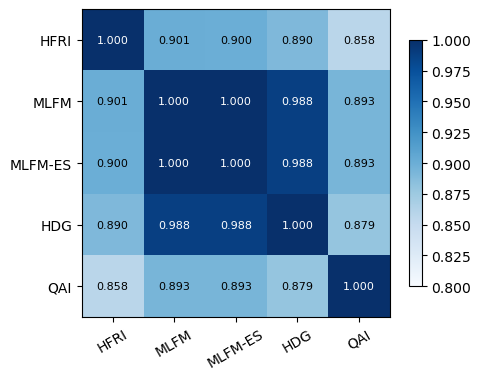

corr
MLFM HDG     0.9878
     MLFM-ES 0.9999
HFRI QAI     0.8578
HDG  QAI     0.8790

In [5]:
C = H.corr()
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(C, cmap='Blues', vmin=0.8, vmax=1)
ax.set_xticks(range(len(C))); ax.set_xticklabels(C.columns, rotation=30)
ax.set_yticks(range(len(C))); ax.set_yticklabels(C.index)
for i in range(len(C)):
    for j in range(len(C)):
        ax.text(j, i, f'{C.iloc[i, j]:.3f}', ha='center', va='center', fontsize=8, color='white' if C.iloc[i, j] > 0.95 else 'black')
fig.colorbar(im, ax=ax, shrink=.8)
plt.show()
pairs = C.where(np.triu(np.ones(C.shape, bool), 1)).stack().dropna().sort_values()
pd.concat([pairs.tail(2), pairs.head(2)]).to_frame('corr')

### 2.6

In [6]:
fit, rep = replicate(H['HFRI'], F)
display(fit.params.to_frame('estimate'))
rep

,estimate
const,0.0011
SPY US Equity,0.0435
USGG3M Index,0.3249
EEM US Equity,0.0856
EFA US Equity,0.0740
EUO US Equity,0.0296
IWM US Equity,0.1458


r-squared        0.8427
tracking error   0.0233
dtype: float64

### 2.7

,out-of-sample,full-sample OLS (same months)
correlation,0.9013,0.9220
OOS r-squared,0.8055,0.8473
tracking error,0.0275,0.0247
target mean,0.0641,0.0641
replication mean,0.0479,0.0571


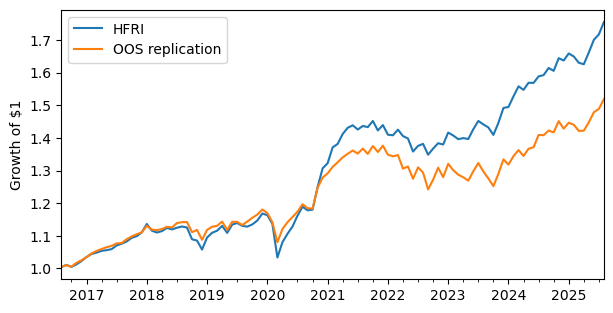

In [7]:
pred = rolling_oos(H['HFRI'], F)
display(pd.DataFrame({'out-of-sample': oos_stats(H['HFRI'], pred), 'full-sample OLS (same months)': oos_stats(H['HFRI'], fit.fittedvalues.loc[pred.index])}))
cum = (1 + pd.DataFrame({'HFRI': H['HFRI'].loc[pred.index], 'OOS replication': pred})).cumprod()
cum.plot(figsize=(7, 3.5), ylabel='Growth of $1'); plt.show()

# Part II: Unconstrained Optimization

In [8]:
import pandas as pd, numpy as np, statsmodels.api as sm
pd.options.display.float_format = '{:.4f}'.format

FILE = 'spx_returns_weekly.xlsx'
TICKS = ['AAPL', 'NVDA', 'MSFT', 'GOOGL', 'AMZN', 'META', 'TSLA', 'AVGO', 'BRK/B', 'LLY']
ETF = 'SPY'
R = pd.read_excel(FILE, sheet_name='spx returns', index_col=0)[TICKS].join(
    pd.read_excel(FILE, sheet_name='additional returns', index_col=0)[ETF])
P = 52

def risk_stats(R):
    m, v = R.mean() * P, R.std() * np.sqrt(P)
    wealth = (1 + R).cumprod()
    return pd.DataFrame({'mean': m, 'vol': v, 'sharpe': m / v, 'skewness': R.skew(),
                         'excess kurtosis': R.kurt(), 'max drawdown': (wealth / wealth.cummax() - 1).min()})

def regress(y, x):
    fit = sm.OLS(y, sm.add_constant(x)).fit()
    a, b = fit.params
    return pd.Series({'alpha': a * P, 'beta': b, 'info ratio': a * P / (fit.resid.std() * np.sqrt(P)), 'r-squared': fit.rsquared})

def optimized_weights(returns, dropna=True, scale_cov=1):
    if dropna:
        returns = returns.dropna()
    covmat_full = returns.cov()
    covmat_diag = np.diag(np.diag(covmat_full))
    covmat = scale_cov * covmat_full + (1 - scale_cov) * covmat_diag
    weights = np.linalg.solve(covmat, returns.mean())
    weights = weights / weights.sum()
    if returns.mean() @ weights < 0:
        weights = -weights
    return pd.DataFrame(weights, index=returns.columns)

def port_stats(w, R):
    p = R @ w
    m, v = p.mean() * P, p.std() * np.sqrt(P)
    return pd.Series({'mean': m, 'vol': v, 'sharpe': m / v})

R.index[[0, -1]], R.shape

(DatetimeIndex(['2015-07-10', '2026-06-26'], dtype='datetime64[ns]', name='date', freq=None),
 (573, 11))

## 1. Risk Statistics
### 1.1

In [9]:
S = risk_stats(R)
S

,mean,vol,sharpe,skewness,excess kurtosis,max drawdown
AAPL,0.2485,0.2776,0.8952,-0.1821,1.8047,-0.3464
NVDA,0.6453,0.4544,1.4202,0.3509,1.4917,-0.6594
MSFT,0.2353,0.2378,0.9894,0.1327,1.6850,-0.3505
GOOGL,0.2698,0.2873,0.9392,0.5326,3.1040,-0.4186
AMZN,0.2613,0.3045,0.8581,-0.0872,1.3419,-0.5483
META,0.2320,0.3575,0.6491,0.0370,3.4901,-0.7603
TSLA,0.4375,0.5797,0.7548,0.5593,1.6335,-0.7225
AVGO,0.3939,0.3825,1.0297,0.6429,3.2722,-0.4004
BRK/B,0.1348,0.1882,0.7164,-0.1865,2.5339,-0.2648
LLY,0.3014,0.2982,1.0107,0.1383,1.9761,-0.3448


### 1.3

In [10]:
REG = pd.DataFrame({t: regress(R[t], R[ETF]) for t in TICKS + [ETF]}).T
REG.loc[ETF, 'info ratio'] = np.nan
REG.sort_values('info ratio', ascending=False)

,alpha,beta,info ratio,r-squared
NVDA,0.3960,1.7179,1.1329,0.4083
LLY,0.2135,0.6058,0.7622,0.1179
AVGO,0.1873,1.4231,0.6297,0.3955
MSFT,0.0878,1.0162,0.5337,0.5216
GOOGL,0.1096,1.1039,0.5016,0.4217
AAPL,0.0865,1.1161,0.4247,0.4618
AMZN,0.1006,1.1066,0.4189,0.3773
TSLA,0.1836,1.7490,0.3683,0.2601
META,0.0604,1.1824,0.2038,0.3125
BRK/B,0.0214,0.7818,0.1593,0.4927


## 2. Portfolio Allocation
### 2.1

In [11]:
C = R.corr()
pairs = C.where(np.triu(np.ones(C.shape, bool), 1)).stack().dropna().sort_values()
display(C.style.format('{:.2f}'))
pd.concat([pairs.tail(3), pairs.head(3)]).to_frame('corr')

,AAPL,NVDA,MSFT,GOOGL,AMZN,META,TSLA,AVGO,BRK/B,LLY,SPY
AAPL,1.00,0.48,0.55,0.54,0.46,0.41,0.44,0.51,0.41,0.19,0.68
NVDA,0.48,1.00,0.59,0.45,0.55,0.43,0.41,0.57,0.30,0.16,0.64
MSFT,0.55,0.59,1.00,0.61,0.63,0.57,0.41,0.53,0.36,0.26,0.72
GOOGL,0.54,0.45,0.61,1.00,0.59,0.51,0.37,0.48,0.34,0.17,0.65
AMZN,0.46,0.55,0.63,0.59,1.00,0.53,0.40,0.44,0.27,0.14,0.61
META,0.41,0.43,0.57,0.51,0.53,1.00,0.26,0.40,0.28,0.12,0.56
TSLA,0.44,0.41,0.41,0.37,0.40,0.26,1.00,0.37,0.20,0.13,0.51
AVGO,0.51,0.57,0.53,0.48,0.44,0.40,0.37,1.00,0.30,0.10,0.63
BRK/B,0.41,0.30,0.36,0.34,0.27,0.28,0.20,0.30,1.00,0.30,0.70
LLY,0.19,0.16,0.26,0.17,0.14,0.12,0.13,0.10,0.30,1.00,0.34


,,corr
AAPL,SPY,0.6796
BRK/B,SPY,0.7019
MSFT,SPY,0.7222
AVGO,LLY,0.1045
META,LLY,0.1159
TSLA,LLY,0.1258


In [12]:
C.loc[TICKS, TICKS].replace(1, np.nan).mean().sort_values().to_frame('avg corr with other stocks')

,avg corr with other stocks
LLY,0.1738
BRK/B,0.3050
TSLA,0.3315
META,0.3886
AVGO,0.4130
NVDA,0.4388
AAPL,0.4420
AMZN,0.4452
GOOGL,0.4499
MSFT,0.5005


### 2.2

In [13]:
W = optimized_weights(R)[0]
pd.DataFrame({'weight': W, 'sharpe': S['sharpe']}).sort_values('weight', ascending=False)

,weight,sharpe
BRK/B,1.6962,0.7164
LLY,0.9050,1.0107
NVDA,0.8463,1.4202
GOOGL,0.5513,0.9392
AVGO,0.4543,1.0297
AAPL,0.3532,0.8952
MSFT,0.3013,0.9894
TSLA,0.2005,0.7548
AMZN,0.1292,0.8581
META,0.1002,0.6491


### 2.3

In [14]:
port_stats(W, R).to_frame('tangency')

,tangency
mean,1.0201
vol,0.5222
sharpe,1.9536


### 2.4

In [15]:
drop = W.idxmin()
R2 = R.drop(columns=drop)
W2 = optimized_weights(R2)[0]
display(pd.DataFrame({'original': W, f'without {drop}': W2}).sort_values('original', ascending=False))
display(pd.DataFrame({'original': pd.concat([port_stats(W, R), pd.Series({'gross exposure': W.abs().sum()})]),
              f'without {drop}': pd.concat([port_stats(W2, R2), pd.Series({'gross exposure': W2.abs().sum()})])}))

np.linalg.cond(R.cov()), np.linalg.cond(R2.cov())

,original,without SPY
BRK/B,1.6962,0.0385
LLY,0.9050,0.4309
NVDA,0.8463,0.4049
GOOGL,0.5513,0.1765
AVGO,0.4543,0.1118
AAPL,0.3532,0.0062
MSFT,0.3013,-0.1131
TSLA,0.2005,0.0235
AMZN,0.1292,-0.0344
META,0.1002,-0.0448


,original,without SPY
mean,1.0201,0.4539
vol,0.5222,0.2725
sharpe,1.9536,1.6657
gross exposure,10.0753,1.3847


(206.8020715027622, 30.316556742764448)